In [25]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from aux_func import get_data 
from epiweeks import Week 
import seaborn as sns

In [26]:
challenge = 'dengue_state'

df_dengue = get_data(challenge)
df_dengue.date = pd.to_datetime(df_dengue.date)

#df_dengue = df_dengue.loc[df_dengue.date >= pd.to_datetime(Week(2015,41).startdate())]

df_dengue.head()

,date,adm_1,casos
0,2010-01-03,11,2456
1,2010-01-03,12,760
2,2010-01-03,13,155
3,2010-01-03,14,25
4,2010-01-03,15,115


In [27]:
df = df_dengue.copy()
df["date"] = pd.to_datetime(df["date"])

iso = df["date"].dt.isocalendar()
df["year"] = iso.year.astype(int)
df["week"] = iso.week.astype(int)

# Ano epidêmico:
# EW41-52 pertencem ao ano epidêmico seguinte
df["epiyear"] = np.where(df["week"] >= 41,
                         df["year"] + 1,
                         df["year"])

# -----------------------------------------------------------------------------
# Calcula o pico de cada ano epidêmico
# -----------------------------------------------------------------------------

season_max = (
    df.groupby(["adm_1", "epiyear"], as_index=False)
      .agg(season_max=("casos", "max"))
)

# -----------------------------------------------------------------------------
# Definição dos períodos de validação
# -----------------------------------------------------------------------------

validations = {
    1: {
        "train_end": (2022, 25),
        "start": (2022, 41),
        "end": (2023, 40),
    },
    2: {
        "train_end": (2023, 25),
        "start": (2023, 41),
        "end": (2024, 40),
    },
    3: {
        "train_end": (2024, 25),
        "start": (2024, 41),
        "end": (2025, 40),
    },
    4: {
        "train_end": (2025, 25),
        "start": (2025, 41),
        "end": (2026, 40),
    },
}

# -----------------------------------------------------------------------------
# Funções auxiliares
# -----------------------------------------------------------------------------

def filter_period(df, start, end):
    """
    Seleciona dados entre duas semanas epidemiológicas inclusive.
    start/end = (ano, semana)
    """

    sy, sw = start
    ey, ew = end

    start_mask = (
        (df.year > sy) |
        ((df.year == sy) & (df.week >= sw))
    )

    end_mask = (
        (df.year < ey) |
        ((df.year == ey) & (df.week <= ew))
    )

    return df.loc[start_mask & end_mask]


# -----------------------------------------------------------------------------
# Classificação
# -----------------------------------------------------------------------------

results = []

states = sorted(df.adm_1.unique())

for state in states:

    df_state = df[df.adm_1 == state]
    season_state = season_max[season_max.adm_1 == state]

    for validation, info in validations.items():

        train_year, train_week = info["train_end"]

        # Dados disponíveis até a semana 25
        train_df = df_state[
            (df_state.year < train_year) |
            ((df_state.year == train_year) &
             (df_state.week <= train_week))
        ]

        # Apenas anos epidêmicos completos
        completed_seasons = sorted(train_df.epiyear.unique())

        peaks = (
            season_state[
                season_state.epiyear.isin(completed_seasons)
            ]
            .season_max
            .values
        )

        threshold = np.percentile(peaks, 80)

        # Pico observado durante a validação
        validation_df = filter_period(
            df_state,
            info["start"],
            info["end"]
        )

        validation_peak = validation_df.casos.max()

        classification = (
            "epidemic"
            if validation_peak >= threshold
            else "endemic"
        )

        results.append({
            "adm_1": state,
            "validation": validation,
            "threshold": threshold,
            "validation_peak": validation_peak,
            "classification": classification,
        })

results = pd.DataFrame(results)

results

,adm_1,validation,threshold,validation_peak,classification
0,11,1,588.0,864,epidemic
1,11,2,647.6,604,endemic
2,11,3,639.8,142,endemic
3,11,4,632.0,72,endemic
4,12,1,2007.6,288,endemic
...,...,...,...,...,...
103,52,4,8872.0,5905,endemic
104,53,1,2470.0,1207,endemic
105,53,2,2115.0,23166,epidemic
106,53,3,3229.4,469,endemic


In [28]:
results.classification.value_counts()

classification
endemic     80
epidemic    28
Name: count, dtype: int64

In [29]:
df_rank = pd.read_csv(f'predictions/rank_ratio_{challenge}.csv.gz')

df_rank = df_rank.loc[df_rank.adm_1 != 32]
df_rank = df_rank.merge(results[['adm_1', 'validation', 'classification']], on = ['adm_1', 'validation'])
df_rank.head()

,model,adm_1,validation,wis,wis_baseline,wis_ratio,region,classification
0,3rd_imdc_-unifesp-_-4mosqueteiras-,11,1,205.38,101.894535,2.015613,North,epidemic
1,3rd_imdc_-unifesp-_-4mosqueteiras-,11,2,68.46,31.277812,2.188772,North,endemic
2,3rd_imdc_-unifesp-_-4mosqueteiras-,11,3,30.97,24.740000,1.251819,North,endemic
3,3rd_imdc_-unifesp-_-4mosqueteiras-,11,4,42.33,26.550000,1.594350,North,endemic
4,3rd_imdc_-unifesp-_-4mosqueteiras-,12,1,37.72,30.964984,1.218150,North,endemic


In [30]:
df_rank.groupby(['classification'])[['wis_ratio']].median()

,wis_ratio
classification,
endemic,1.134770
epidemic,1.119815


In [31]:
2808/104

27.0

In [32]:
df_rank.shape

(2808, 8)

In [33]:
df_rank['below_1'] = np.where(df_rank.wis_ratio < 1, 1, 0)

df_rank.groupby('classification')[['below_1']].sum()

,below_1
classification,
endemic,800
epidemic,249


In [34]:
df_rank.classification.value_counts()

classification
endemic     2106
epidemic     702
Name: count, dtype: int64

In [44]:
800/(2106)

0.3798670465337132

In [45]:
249/702

0.3547008547008547

<Axes: xlabel='classification', ylabel='wis_ratio'>

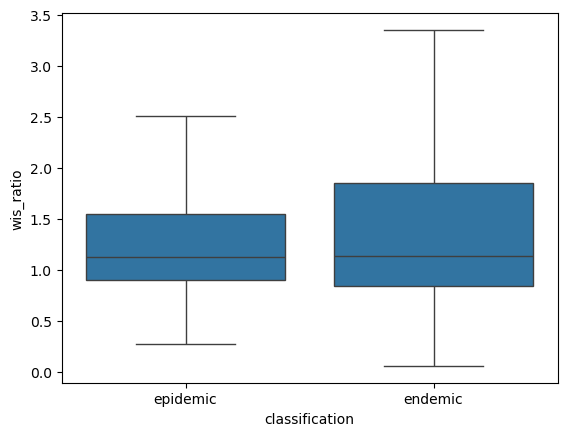

In [46]:
sns.boxplot(data= df_rank, x = 'classification', y = 'wis_ratio', showfliers=False)

<Axes: xlabel='classification', ylabel='wis_ratio'>

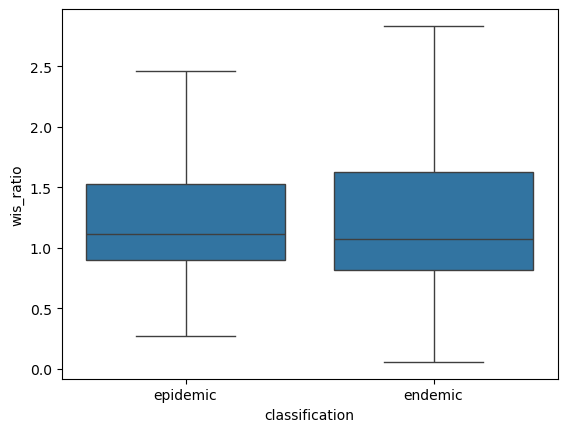

In [38]:
sns.boxplot(data= df_rank.loc[df_rank.wis_ratio < 4], x = 'classification', y = 'wis_ratio', showfliers=False)

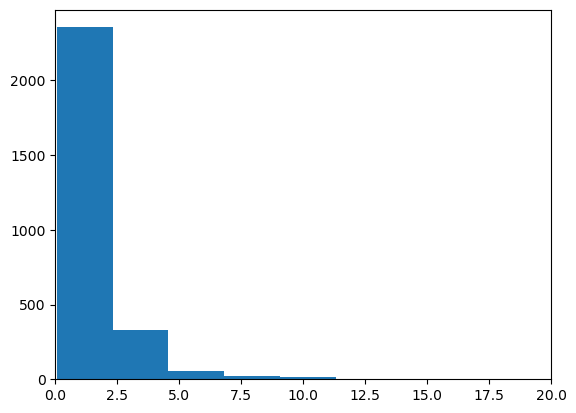

In [39]:
_,ax = plt.subplots()
ax.hist(df_rank.wis_ratio, bins = 100)

ax.set_xlim([0, 20])

plt.show()

In [40]:
np.percentile(df_rank.wis_ratio.values, 95)

np.float64(4.229815908091533)

In [41]:
df_rank.loc[df_rank.wis_ratio > 10].shape[0]/df_rank.shape[0]

0.011752136752136752

<Axes: xlabel='classification', ylabel='wis_ratio'>

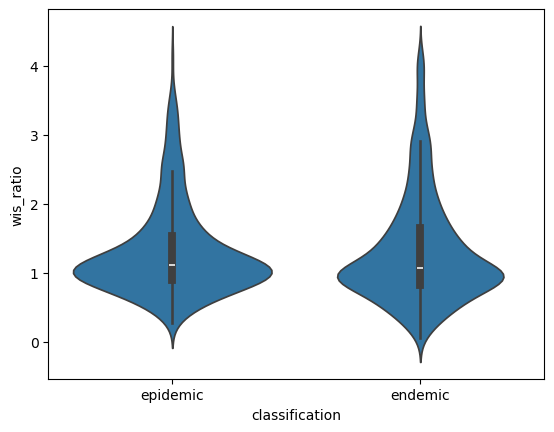

In [42]:
sns.violinplot(data= df_rank.loc[df_rank.wis_ratio < np.percentile(df_rank.wis_ratio.values, 95)], x = 'classification', y = 'wis_ratio')

In [43]:
results.loc[results.classification == 'epidemic'].groupby('adm_1')[['classification']].count()

,classification
adm_1,
11,1
13,1
15,2
16,1
17,1
21,2
22,2
29,1
31,1


In [60]:
from aux_func import rename_models
import seaborn as sns

In [119]:
cat_models = {
    'statistical': [
        'BSC',
        'CORNELL',
        'LNCC_ARP26',
        'EMAP_SARIMAX',
        'FIOCRUZ_MARD',
        'FGV_SAKHAL',
        'PROCC_BB_MODEL'
    ],
    'machine_learning': [
        'FGV_PATTERN-BLUE',
        'AFYA_RIC',
        'FIOCRUZ_ZEROLAGS', 
        'RKI_PH',
        'EMAP_PROPHET',
        'RKI_LSTM_GEO',
        'EMAP_LSTM',
        'UNESP_RECOGNA',
        'EMAP_XGBSILLAS',
        'DS-OKSTATE'
    ],
    'deterministic': [
        'LNCC_SURGE',
        'LNCC_CLIDENGO',
        'ISI',
        'UNIFESP',

    ],
    'ensemble': [
        'UNI_DEL_VALLE',
        'IFGW',
        'CERI',
        'PURDUE_NEURALEARTH',
        'NUS_CERM',    
        'PUCRIO',

    ],
}

cat_models = {
    'BSC': 'statistical',
    'CORNELL': 'statistical',
    'LNCC_ARP26': 'statistical',
    'EMAP_SARIMAX': 'statistical',
    'FIOCRUZ_MARD': 'statistical',
    'EMAP_SAKHAL': 'statistical',
    'PROCC': 'statistical',
    'EMAP_BLUE': 'machine_learning',
    'AFYA': 'machine_learning',
    'FIOCRUZ_ZEROLAGS': 'machine_learning',
    'RKI_PH': 'machine_learning',
    'EMAP_PROPHET': 'machine_learning',
    'RKI_LSTM': 'machine_learning',
    'EMAP_LSTM': 'machine_learning',
    'UNESP': 'machine_learning',
    'EMAP_XGB': 'machine_learning',
    'DS-OKSTATE': 'machine_learning',
    'LNCC_SURGE': 'mechanistic',
    'LNCC_CLIDENGO': 'mechanistic',
    'ISI': 'mechanistic',
    'UNIFESP': 'mechanistic',
    'UNI_DEL_VALLE': 'ensemble',
    'IFGW': 'ensemble',
    'CERI': 'ensemble',
    'PURDUE': 'ensemble',
    'NUS-CERM': 'ensemble',
    'PUCRIO': 'ensemble'
}

In [121]:
len(cat_models.keys())

27

In [122]:
df_rank['category'] = df_rank['model'].replace(rename_models).replace(cat_models)

df_rank.head()

,model,adm_1,validation,wis,wis_baseline,wis_ratio,region,classification,below_1,category
0,3rd_imdc_-unifesp-_-4mosqueteiras-,11,1,205.38,101.894535,2.015613,North,epidemic,0,mechanistic
1,3rd_imdc_-unifesp-_-4mosqueteiras-,11,2,68.46,31.277812,2.188772,North,endemic,0,mechanistic
2,3rd_imdc_-unifesp-_-4mosqueteiras-,11,3,30.97,24.740000,1.251819,North,endemic,0,mechanistic
3,3rd_imdc_-unifesp-_-4mosqueteiras-,11,4,42.33,26.550000,1.594350,North,endemic,0,mechanistic
4,3rd_imdc_-unifesp-_-4mosqueteiras-,12,1,37.72,30.964984,1.218150,North,endemic,0,mechanistic


In [123]:
df_rank.model.unique()

<ArrowStringArray>
[                            '3rd_imdc_-unifesp-_-4mosqueteiras-',
                                              '3rd_imdc_afya_ric',
                                               '3rd_imdc_bsc_ghr',
                              '3rd_imdc_ceri_returnoftheforecast',
                                      '3rd_imdc_cornell_bentolab',
                             '3rd_imdc_emap_epidematicos_prophet',
                       '3rd_imdc_emap_epidematicos_sarimax_state',
                                             '3rd_imdc_emap_lstm',
                                        '3rd_imdc_emap_xgbsillas',
                                      '3rd_imdc_fgv_pattern-blue',
                                            '3rd_imdc_fgv_sakhal',
                                          '3rd_imdc_fiocruz_mard',
                                      '3rd_imdc_fiocruz_zerolags',
                                '3rd_imdc_ifgw_inframind-proteus',
                                        '3r

In [124]:
df_rank.category.unique()

<ArrowStringArray>
['mechanistic', 'machine_learning', 'statistical', 'ensemble']
Length: 4, dtype: str

In [125]:
df_rank.category.isnull().sum()

np.int64(0)

/tmp/ipykernel_17546/802130441.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


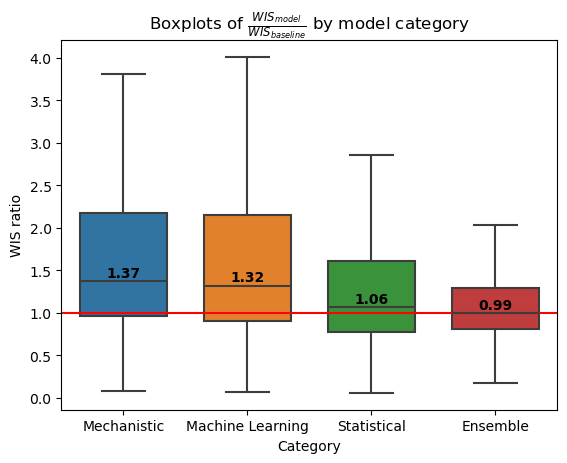

In [128]:
_, ax = plt.subplots()

sns.boxplot(data = df_rank.loc[df_rank.model != '3rd_imdc_procc_bb_model'], x = 'category', y = 'wis_ratio', 
            hue = 'category', showfliers = False,
    linewidth=1.5,
    width=0.7
            )

ax.axhline(1, color = 'red')

medians = df_rank.loc[df_rank.model != '3rd_imdc_procc_bb_model'].groupby('category')['wis_ratio'].median()

medians  = medians[['mechanistic', 'machine_learning', 'statistical', 'ensemble']]

# Escreve o valor sobre cada mediana
for i, (cat, median) in enumerate(medians.items()):
    ax.text(
        i, median + 0.02,          # ajuste o 0.02 conforme a escala
        f'{median:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

labels = [
    label.get_text().replace('_', ' ').title()
    for label in ax.get_xticklabels()
]

ax.set_xticklabels(labels)

ax.set_ylabel('WIS ratio')

ax.set_xlabel('Category')

ax.set_title(r'Boxplots of $\frac{WIS_{model}}{WIS_{baseline}}$ by model category')

plt.show()


/tmp/ipykernel_17546/338744328.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


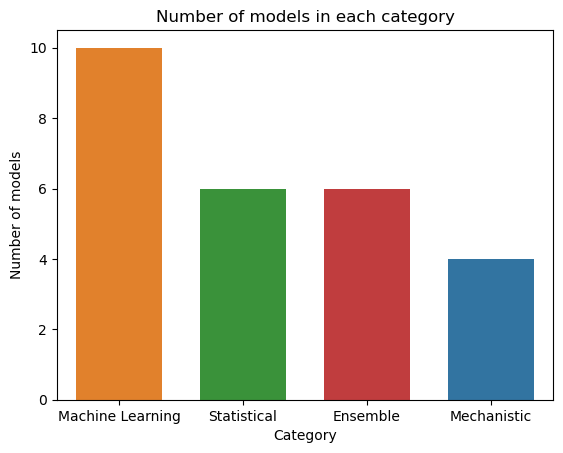

In [129]:
_, ax = plt.subplots()

counts = (
    df_rank.loc[df_rank.model != '3rd_imdc_procc_bb_model'].drop_duplicates(subset=['category', 'model']).loc[: , 'category']
    .value_counts()
    .rename_axis('category')
    .reset_index(name='count')
)

sns.barplot(
    data=counts,
    x='category',
    y='count',
    hue='category',
    linewidth=1.5,
    width=0.7,
    ax=ax,
    hue_order = ['mechanistic', 'machine_learning', 'statistical', 'ensemble'],
)

ax.set_ylabel('Number of models')

ax.set_xlabel('Category')

labels = [
    label.get_text().replace('_', ' ').title()
    for label in ax.get_xticklabels()
]

ax.set_xticklabels(labels)

ax.set_title(r'Number of models in each category')

plt.show()


In [83]:
medians[['deterministic', 'machine_learning', 'statistical', 'ensemble']]

category
deterministic       1.368513
machine_learning    1.318865
statistical         1.063115
ensemble            0.992169
Name: wis_ratio, dtype: float64